In [1]:
import json

from collections import Counter
import numpy as np

import matplotlib.pyplot as plt
import nltk
from nltk import word_tokenize

from textblob import TextBlob

In [2]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /Users/isabel/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
try:
    with open('./dataProcessed/nurseNotes.json', 'r') as file:
        nurse_notes = json.load(file)
    print("File loaded successfully.")
    
except FileNotFoundError:
    print("Error: The file 'data.json' was not found.")

File loaded successfully.


In [4]:
def text_statistics(texts):
    lengths = [len(t) for t in texts]
    all_tokens = [word_tokenize(t) for t in texts]
    word_counts = [len(tok) for tok in all_tokens]

    all_words = [w for tok in all_tokens for w in tok]
    vocab = set(all_words)

    all_words = [w for t in texts for w in word_tokenize(t)]
    counter = Counter(all_words)

    ngrams = []
    for tokens in all_tokens:
        ngrams += zip(*[tokens[i:] for i in range(2)])

    counter_ngrams = Counter(ngrams)

    polarities = []
    for i, text in enumerate(texts[:5]):
        polarity = TextBlob(text).sentiment.polarity
        polarities.append(polarity)


    print("----- General Stats -----")
    print(f"Number of texts: {len(texts)}")
    print(f"Total words: {len(all_words)}")
    print(f"Unique words (vocab size): {len(vocab)}")

    print("----- Length Stats -----")
    print(f"Average text length (characters): {sum(lengths)/len(lengths)}")
    print(f"Average word count per text: {sum(word_counts)/len(word_counts)}")
    print(f"Shortest text word count: {min(word_counts)}")
    print(f"Longest text word count: {max(word_counts)}")

    print("----- Most Common N-GRAMS -----")
    for word, freq in counter_ngrams.most_common(10):
        print(f"{word} -> {freq}")

    print("----- Most Common Words -----")
    for gram, freq in counter.most_common(10):
        print("".join(gram), "->", freq)

    print("----- Sentiment -----")
    print(f"Average polarity: {np.array(polarities).mean()}")


In [5]:
def plot_word_distribution(texts):
    word_counts = [len(word_tokenize(t)) for t in texts]

    plt.figure()
    plt.hist(word_counts, bins=20)
    plt.title("Word Count Distribution per Text")
    plt.xlabel("Words per text")
    plt.ylabel("Frequency")
    plt.show()

In [6]:
def plot_top_words(texts, n):
    all_words = [w for t in texts for w in word_tokenize(t)]
    counter = Counter(all_words)
    common = counter.most_common(n)

    words = [w for w, _ in common]
    freqs = [f for _, f in common]

    plt.figure()
    plt.bar(words, freqs)
    plt.title("Most Common Words")
    plt.xticks(rotation=45)
    plt.show()

-----------P1-----------
----- General Stats -----
Number of texts: 600
Total words: 8212
Unique words (vocab size): 562
----- Length Stats -----
Average text length (characters): 91.54833333333333
Average word count per text: 13.686666666666667
Shortest text word count: 5
Longest text word count: 71
----- Most Common N-GRAMS -----
('med', 'take') -> 190
('resident', 'appear') -> 169
('care', 'need') -> 158
('take', 'chart') -> 143
('good', 'form') -> 133
('give', 'chart') -> 129
('assist', 'care') -> 116
('med', 'give') -> 111
('safety', 'check') -> 108
('appear', 'good') -> 107
----- Most Common Words -----
resident -> 580
care -> 352
med -> 322
chart -> 290
check -> 283
appear -> 236
need -> 226
take -> 214
assist -> 213
nil -> 205
----- Sentiment -----
Average polarity: 0.11833333333333333


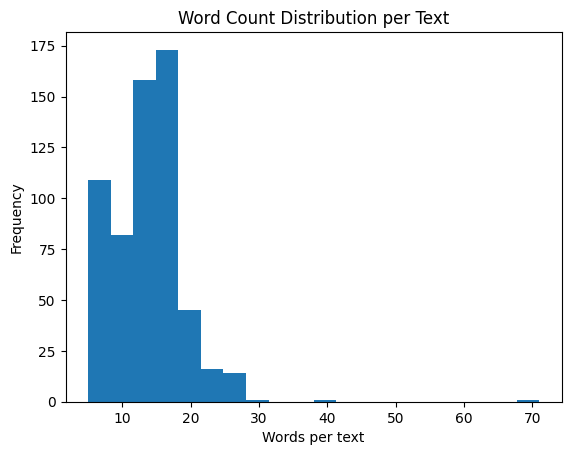

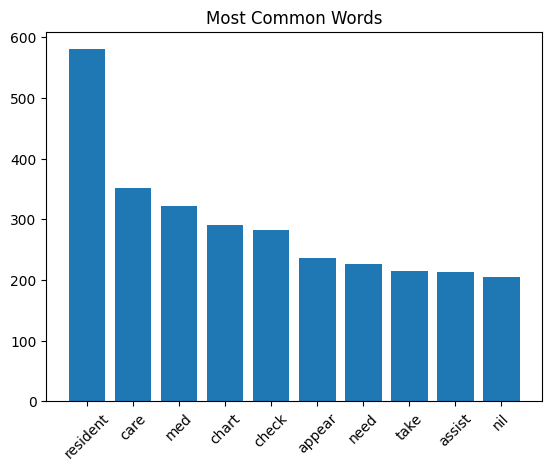

-----------P10-----------
----- General Stats -----
Number of texts: 625
Total words: 11241
Unique words (vocab size): 839
----- Length Stats -----
Average text length (characters): 117.8768
Average word count per text: 17.9856
Shortest text word count: 5
Longest text word count: 66
----- Most Common N-GRAMS -----
('safety', 'check') -> 335
('resident', 'appear') -> 218
('settle', 'night') -> 168
('take', 'chart') -> 167
('care', 'need') -> 162
('good', 'form') -> 147
('med', 'take') -> 143
('check', 'maintain') -> 121
('asleep', 'check') -> 117
('check', 'go') -> 110
----- Most Common Words -----
resident -> 616
check -> 488
care -> 429
need -> 423
safety -> 343
assist -> 310
chart -> 303
take -> 270
nil -> 256
appear -> 254
----- Sentiment -----
Average polarity: 0.2393939393939394


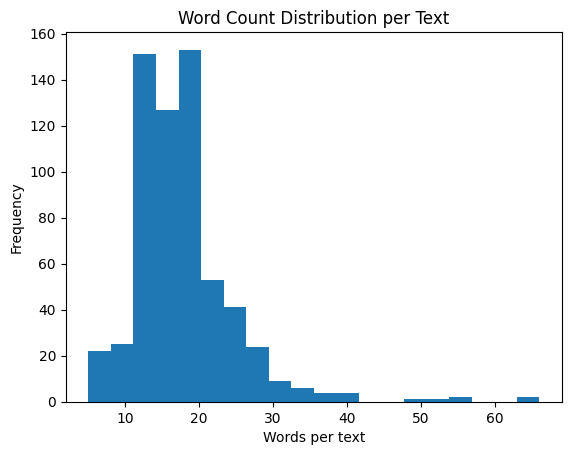

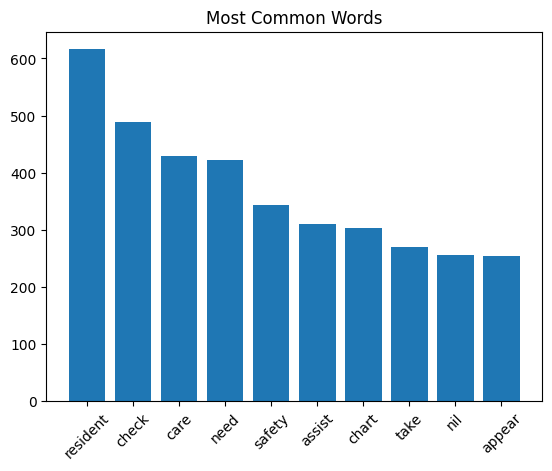

-----------P11-----------
----- General Stats -----
Number of texts: 576
Total words: 9162
Unique words (vocab size): 453
----- Length Stats -----
Average text length (characters): 103.84722222222223
Average word count per text: 15.90625
Shortest text word count: 5
Longest text word count: 41
----- Most Common N-GRAMS -----
('safety', 'check') -> 321
('good', 'form') -> 211
('resident', 'appear') -> 198
('care', 'need') -> 161
('nil', 'new') -> 157
('appear', 'good') -> 125
('asleep', 'check') -> 124
('settle', 'night') -> 117
('check', 'go') -> 113
('need', 'attend') -> 110
----- Most Common Words -----
resident -> 623
check -> 477
care -> 418
need -> 335
safety -> 335
nil -> 325
chart -> 267
good -> 259
appear -> 233
form -> 230
----- Sentiment -----
Average polarity: 0.346969696969697


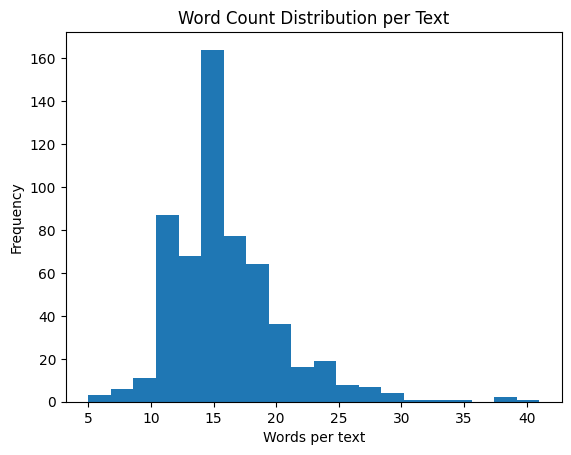

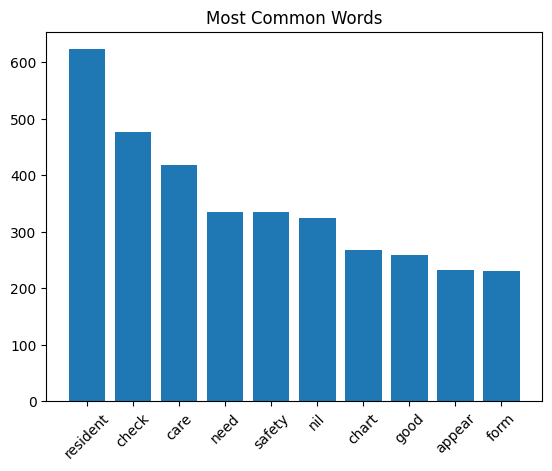

-----------P12-----------
----- General Stats -----
Number of texts: 604
Total words: 11387
Unique words (vocab size): 564
----- Length Stats -----
Average text length (characters): 123.58443708609272
Average word count per text: 18.852649006622517
Shortest text word count: 5
Longest text word count: 45
----- Most Common N-GRAMS -----
('eye', 'care') -> 255
('safety', 'check') -> 203
('good', 'form') -> 193
('check', 'continue') -> 164
('resident', 'appear') -> 162
('early', 'nocte') -> 150
('form', 'assist') -> 126
('settle', 'sleep') -> 121
('resident', 'good') -> 116
('resident', 'settle') -> 107
----- Most Common Words -----
care -> 660
resident -> 588
eye -> 378
good -> 328
continue -> 285
medication -> 279
form -> 277
give -> 253
assist -> 249
sleep -> 247
----- Sentiment -----
Average polarity: 0.2038095238095238


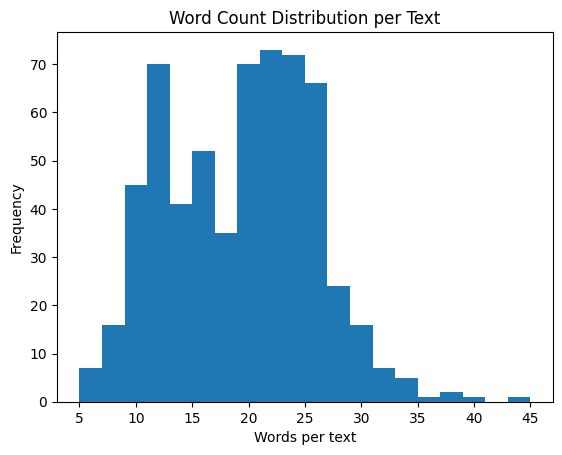

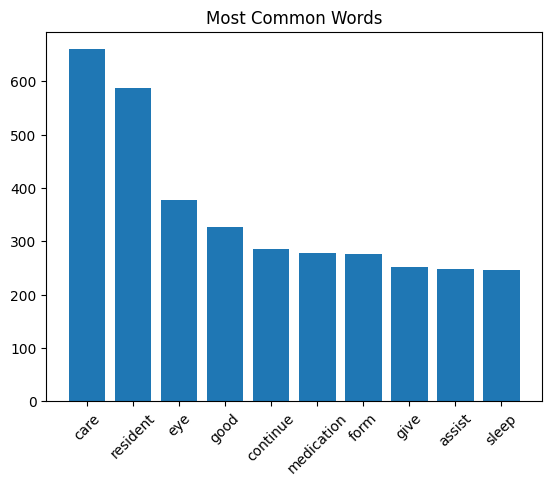

-----------P13-----------
----- General Stats -----
Number of texts: 611
Total words: 11242
Unique words (vocab size): 546
----- Length Stats -----
Average text length (characters): 122.28968903436989
Average word count per text: 18.399345335515548
Shortest text word count: 5
Longest text word count: 35
----- Most Common N-GRAMS -----
('resident', 'appear') -> 181
('care', 'need') -> 179
('safety', 'check') -> 171
('good', 'form') -> 154
('settle', 'sleep') -> 148
('check', 'continue') -> 139
('med', 'give') -> 138
('assist', 'bed') -> 136
('form', 'assist') -> 129
('give', 'chart') -> 123
----- Most Common Words -----
resident -> 622
assist -> 435
good -> 342
care -> 333
give -> 273
appear -> 265
med -> 249
need -> 246
bed -> 241
nil -> 241
----- Sentiment -----
Average polarity: 0.17333333333333328


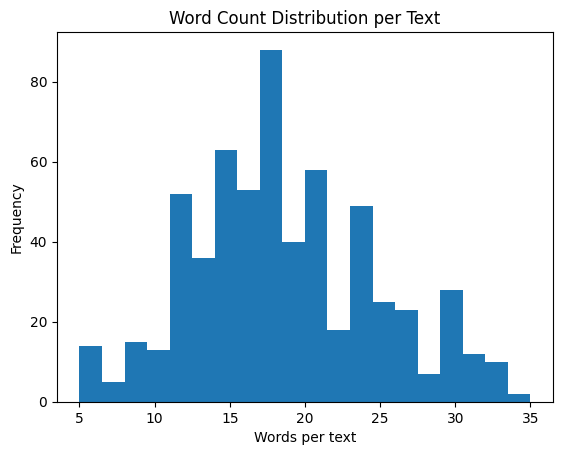

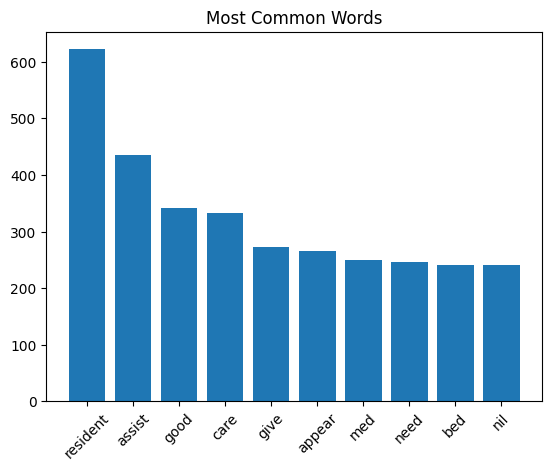

-----------P14-----------
----- General Stats -----
Number of texts: 615
Total words: 9195
Unique words (vocab size): 647
----- Length Stats -----
Average text length (characters): 96.47317073170731
Average word count per text: 14.951219512195122
Shortest text word count: 5
Longest text word count: 47
----- Most Common N-GRAMS -----
('care', 'need') -> 322
('good', 'form') -> 226
('med', 'take') -> 200
('assist', 'care') -> 185
('take', 'chart') -> 183
('resident', 'appear') -> 172
('skin', 'care') -> 141
('appear', 'good') -> 121
('need', 'attend') -> 119
('care', 'continue') -> 116
----- Most Common Words -----
resident -> 594
care -> 581
assist -> 395
need -> 391
med -> 335
chart -> 307
check -> 290
form -> 261
good -> 242
take -> 232
----- Sentiment -----
Average polarity: 0.38


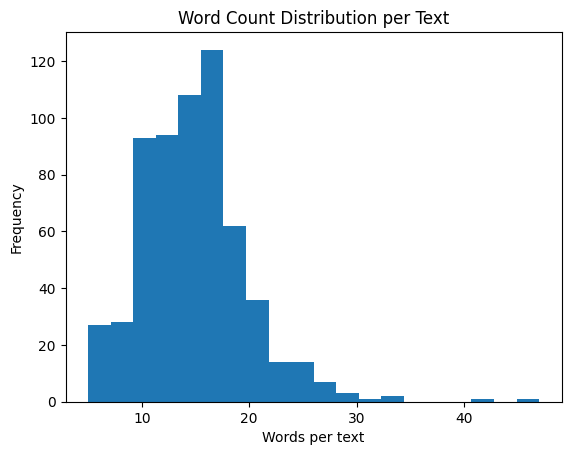

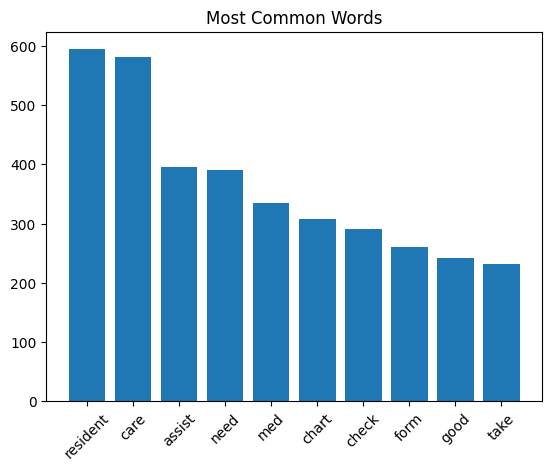

-----------P15-----------
----- General Stats -----
Number of texts: 485
Total words: 9345
Unique words (vocab size): 781
----- Length Stats -----
Average text length (characters): 127.50309278350515
Average word count per text: 19.2680412371134
Shortest text word count: 5
Longest text word count: 153
----- Most Common N-GRAMS -----
('settle', 'sleep') -> 142
('resident', 'settle') -> 133
('good', 'form') -> 118
('resident', 'appear') -> 117
('safety', 'check') -> 115
('give', 'chart') -> 109
('nil', 'new') -> 102
('care', 'need') -> 100
('nocte', 'medication') -> 97
('med', 'give') -> 96
----- Most Common Words -----
resident -> 503
settle -> 262
give -> 255
pain -> 236
good -> 231
sleep -> 231
care -> 200
medication -> 190
nil -> 166
form -> 163
----- Sentiment -----
Average polarity: 0.15229797979797982


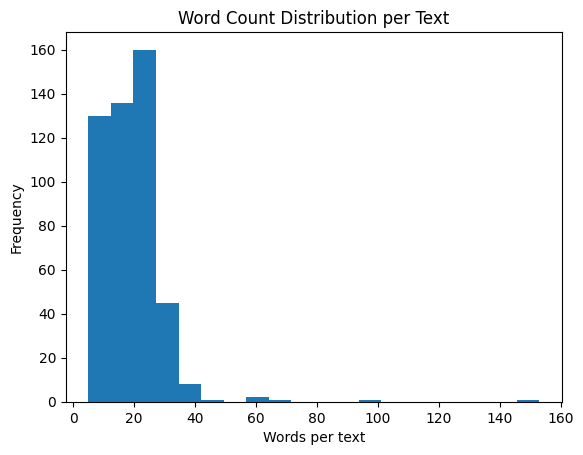

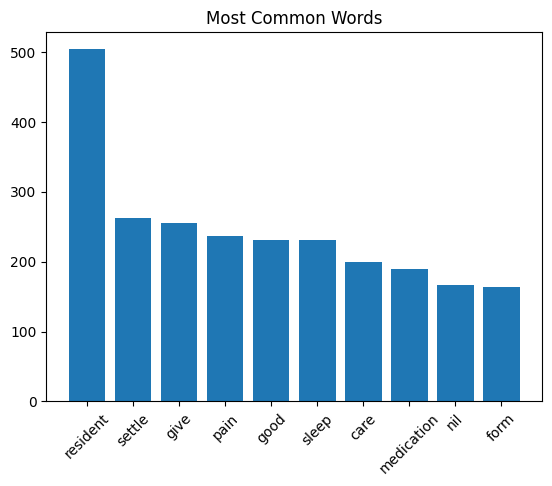

-----------P16-----------
----- General Stats -----
Number of texts: 591
Total words: 10619
Unique words (vocab size): 662
----- Length Stats -----
Average text length (characters): 117.11844331641286
Average word count per text: 17.967851099830796
Shortest text word count: 5
Longest text word count: 163
----- Most Common N-GRAMS -----
('safety', 'check') -> 290
('resident', 'appear') -> 230
('good', 'form') -> 179
('take', 'chart') -> 151
('nil', 'new') -> 151
('med', 'take') -> 142
('settle', 'night') -> 128
('care', 'need') -> 121
('asleep', 'check') -> 114
('appear', 'good') -> 108
----- Most Common Words -----
resident -> 602
check -> 432
care -> 412
need -> 404
nil -> 321
assist -> 305
chart -> 301
safety -> 300
take -> 265
med -> 263
----- Sentiment -----
Average polarity: 0.22772727272727272


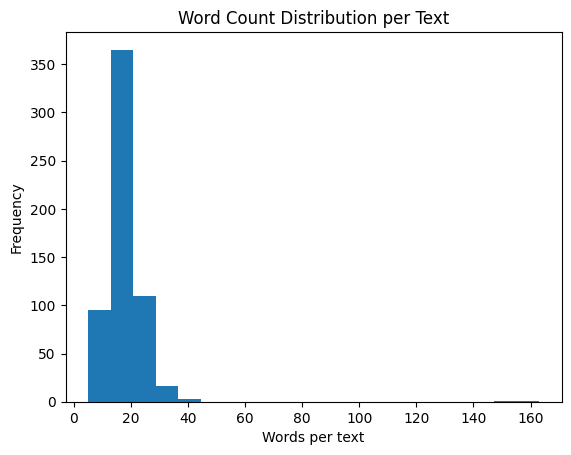

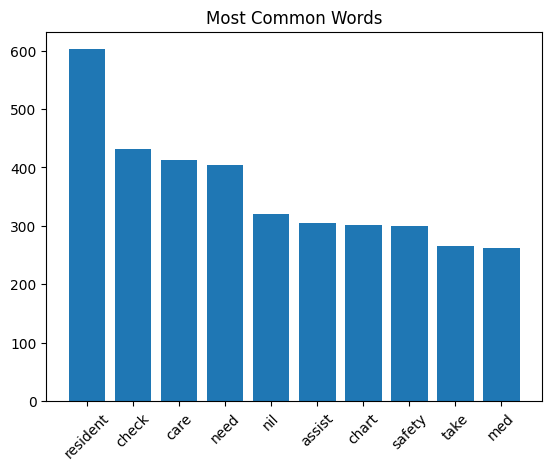

-----------P17-----------
----- General Stats -----
Number of texts: 602
Total words: 10149
Unique words (vocab size): 617
----- Length Stats -----
Average text length (characters): 113.33388704318936
Average word count per text: 16.858803986710964
Shortest text word count: 5
Longest text word count: 50
----- Most Common N-GRAMS -----
('safety', 'check') -> 205
('settle', 'sleep') -> 183
('resident', 'appear') -> 166
('check', 'continue') -> 156
('self', 'care') -> 133
('good', 'form') -> 118
('nil', 'concern') -> 111
('give', 'chart') -> 105
('continue', 'overnight') -> 102
('night', 'medication') -> 100
----- Most Common Words -----
resident -> 650
settle -> 276
sleep -> 269
medication -> 264
check -> 258
give -> 244
nil -> 244
care -> 237
med -> 227
concern -> 222
----- Sentiment -----
Average polarity: 0.13999999999999999


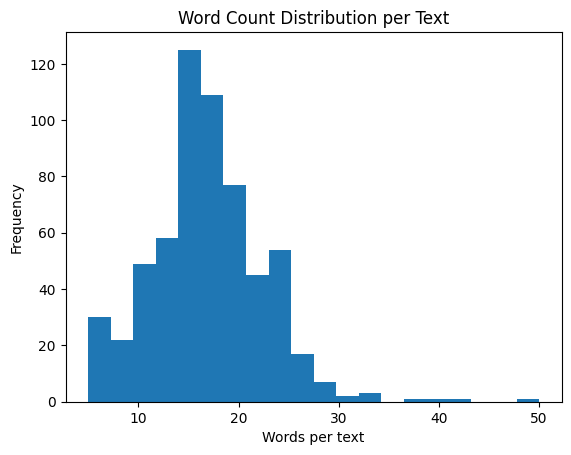

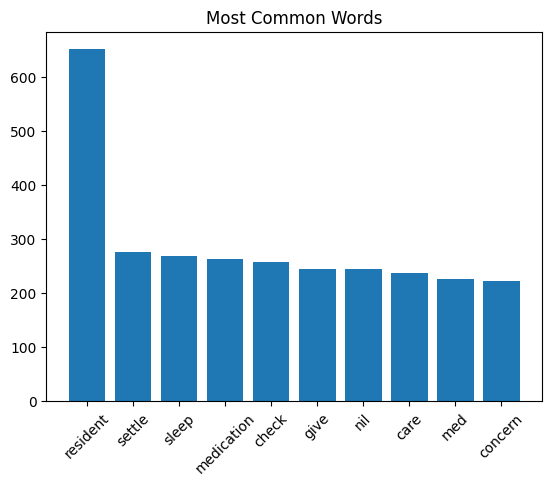

-----------P18-----------
----- General Stats -----
Number of texts: 613
Total words: 9212
Unique words (vocab size): 541
----- Length Stats -----
Average text length (characters): 96.86786296900489
Average word count per text: 15.02773246329527
Shortest text word count: 5
Longest text word count: 41
----- Most Common N-GRAMS -----
('care', 'need') -> 308
('good', 'form') -> 221
('med', 'take') -> 186
('resident', 'appear') -> 166
('give', 'chart') -> 161
('appear', 'good') -> 143
('care', 'continue') -> 142
('assist', 'care') -> 136
('skin', 'care') -> 133
('need', 'attend') -> 124
----- Most Common Words -----
care -> 636
resident -> 576
need -> 376
assist -> 353
med -> 307
check -> 292
chart -> 288
good -> 264
form -> 242
attend -> 224
----- Sentiment -----
Average polarity: 0.2936363636363636


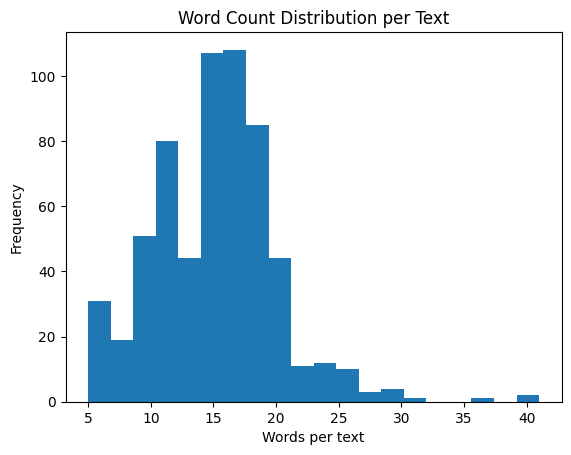

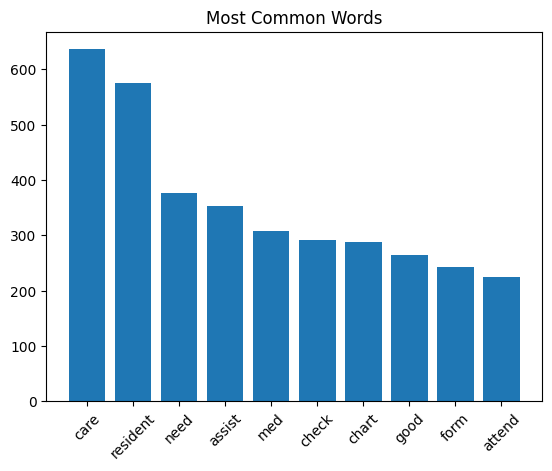

-----------P19-----------
----- General Stats -----
Number of texts: 648
Total words: 8747
Unique words (vocab size): 714
----- Length Stats -----
Average text length (characters): 90.35339506172839
Average word count per text: 13.498456790123457
Shortest text word count: 5
Longest text word count: 71
----- Most Common N-GRAMS -----
('med', 'take') -> 204
('resident', 'appear') -> 186
('take', 'chart') -> 185
('good', 'form') -> 129
('safety', 'check') -> 111
('give', 'chart') -> 111
('med', 'give') -> 102
('appear', 'good') -> 95
('complaint', 'voice') -> 95
('nil', 'complaint') -> 80
----- Most Common Words -----
resident -> 649
med -> 332
chart -> 315
check -> 275
take -> 234
appear -> 227
give -> 188
care -> 175
nil -> 167
form -> 166
----- Sentiment -----
Average polarity: 0.09214285714285712


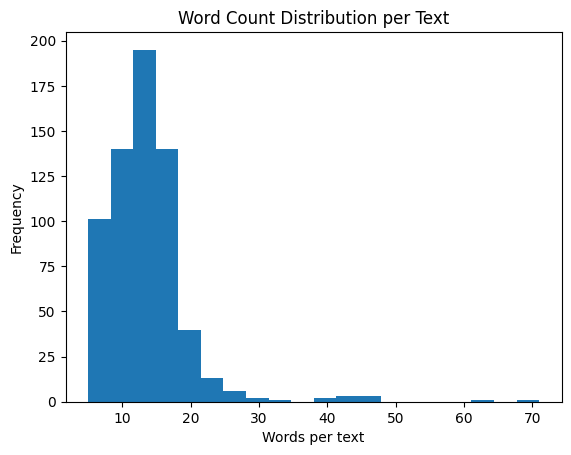

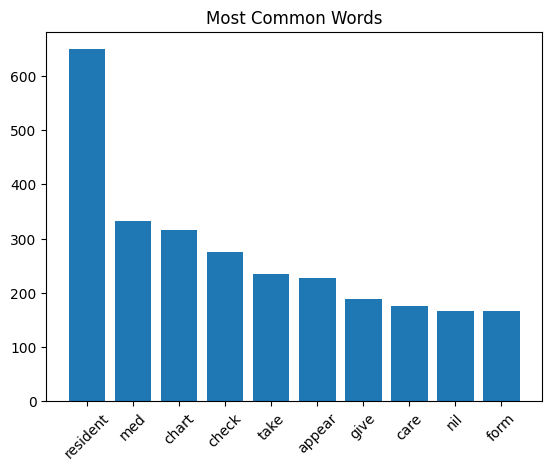

-----------P2-----------
----- General Stats -----
Number of texts: 626
Total words: 11806
Unique words (vocab size): 726
----- Length Stats -----
Average text length (characters): 123.89776357827476
Average word count per text: 18.859424920127797
Shortest text word count: 5
Longest text word count: 74
----- Most Common N-GRAMS -----
('care', 'need') -> 178
('resident', 'appear') -> 164
('check', 'continue') -> 146
('safety', 'check') -> 137
('good', 'form') -> 129
('need', 'attend') -> 107
('continue', 'overnight') -> 100
('give', 'chart') -> 98
('form', 'assist') -> 97
('sleep', 'present') -> 95
----- Most Common Words -----
resident -> 658
care -> 394
assist -> 338
medication -> 259
give -> 258
check -> 253
nil -> 250
need -> 230
med -> 224
appear -> 223
----- Sentiment -----
Average polarity: 0.10444444444444445


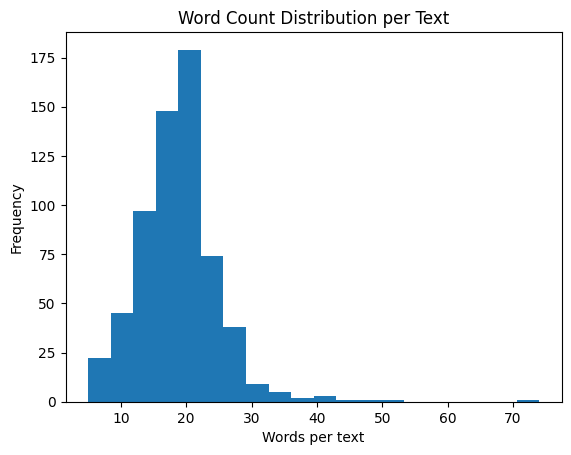

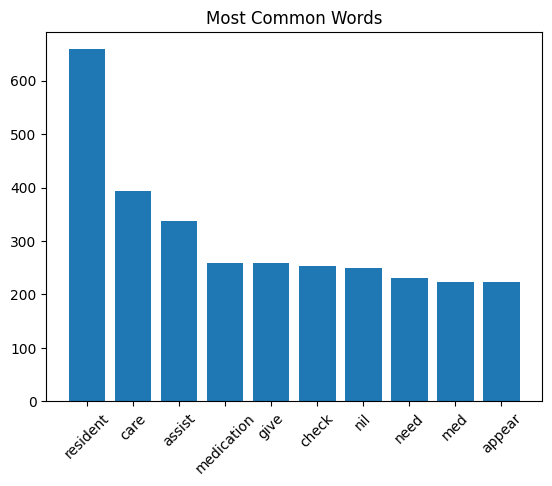

-----------P20-----------
----- General Stats -----
Number of texts: 583
Total words: 8307
Unique words (vocab size): 506
----- Length Stats -----
Average text length (characters): 94.4819897084048
Average word count per text: 14.248713550600343
Shortest text word count: 5
Longest text word count: 92
----- Most Common N-GRAMS -----
('care', 'need') -> 282
('resident', 'appear') -> 210
('good', 'form') -> 200
('med', 'take') -> 192
('take', 'chart') -> 171
('appear', 'good') -> 153
('assist', 'care') -> 139
('need', 'attend') -> 130
('skin', 'care') -> 110
('care', 'continue') -> 101
----- Most Common Words -----
resident -> 566
care -> 481
need -> 403
assist -> 334
med -> 317
chart -> 291
check -> 272
form -> 236
appear -> 234
good -> 220
----- Sentiment -----
Average polarity: 0.20000000000000004


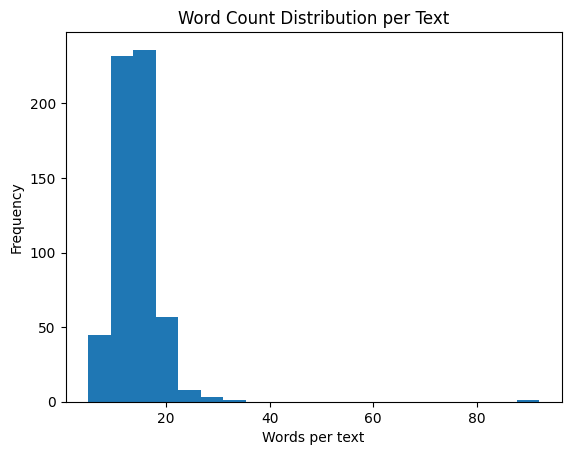

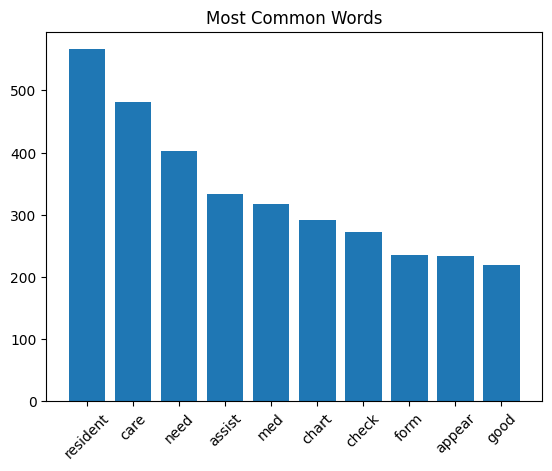

-----------P3-----------
----- General Stats -----
Number of texts: 679
Total words: 10859
Unique words (vocab size): 932
----- Length Stats -----
Average text length (characters): 104.4020618556701
Average word count per text: 15.992636229749632
Shortest text word count: 5
Longest text word count: 92
----- Most Common N-GRAMS -----
('care', 'need') -> 220
('med', 'take') -> 216
('resident', 'appear') -> 207
('good', 'form') -> 193
('take', 'chart') -> 162
('give', 'chart') -> 152
('assist', 'care') -> 144
('safety', 'check') -> 126
('appear', 'good') -> 126
('need', 'attend') -> 120
----- Most Common Words -----
resident -> 713
med -> 372
care -> 361
chart -> 336
form -> 324
give -> 313
need -> 310
check -> 280
appear -> 269
assist -> 265
----- Sentiment -----
Average polarity: 0.17


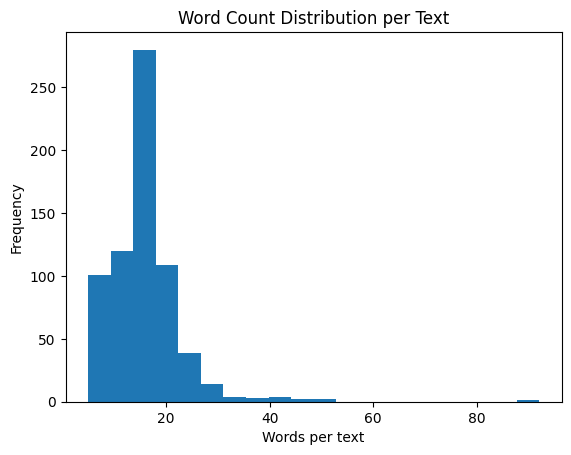

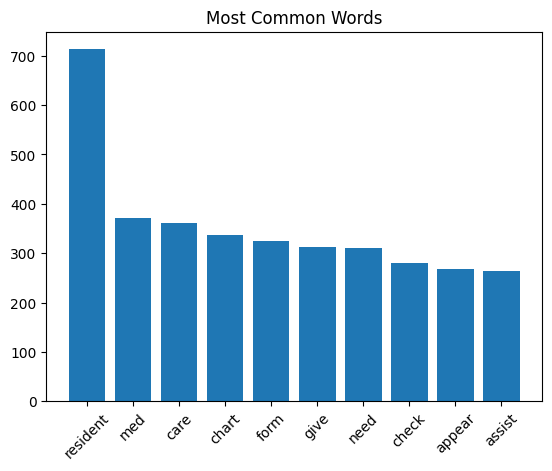

-----------P4-----------
----- General Stats -----
Number of texts: 687
Total words: 11388
Unique words (vocab size): 797
----- Length Stats -----
Average text length (characters): 109.30276564774381
Average word count per text: 16.5764192139738
Shortest text word count: 5
Longest text word count: 92
----- Most Common N-GRAMS -----
('care', 'need') -> 298
('give', 'chart') -> 179
('good', 'form') -> 172
('resident', 'appear') -> 171
('assist', 'care') -> 130
('need', 'attend') -> 119
('appear', 'good') -> 118
('skin', 'care') -> 116
('med', 'take') -> 112
('safety', 'check') -> 92
----- Most Common Words -----
resident -> 695
care -> 643
assist -> 380
need -> 375
continue -> 314
med -> 288
check -> 278
give -> 273
chart -> 255
appear -> 238
----- Sentiment -----
Average polarity: 0.2924242424242424


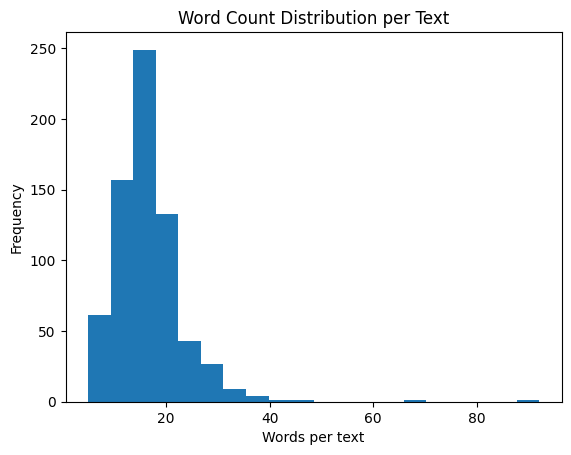

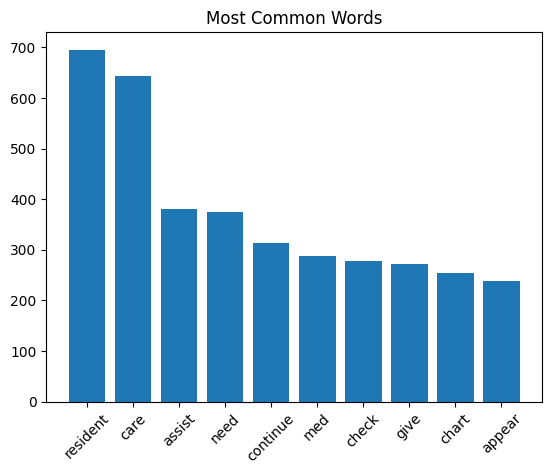

-----------P5-----------
----- General Stats -----
Number of texts: 575
Total words: 7509
Unique words (vocab size): 405
----- Length Stats -----
Average text length (characters): 87.69043478260869
Average word count per text: 13.059130434782608
Shortest text word count: 5
Longest text word count: 37
----- Most Common N-GRAMS -----
('med', 'take') -> 202
('take', 'chart') -> 178
('good', 'form') -> 168
('resident', 'appear') -> 167
('safety', 'check') -> 113
('give', 'chart') -> 111
('med', 'give') -> 101
('appear', 'good') -> 98
('ongoing', 'check') -> 88
('care', 'need') -> 81
----- Most Common Words -----
resident -> 658
med -> 333
chart -> 309
check -> 285
take -> 227
appear -> 222
form -> 205
good -> 192
independent -> 190
care -> 179
----- Sentiment -----
Average polarity: 0.15916666666666668


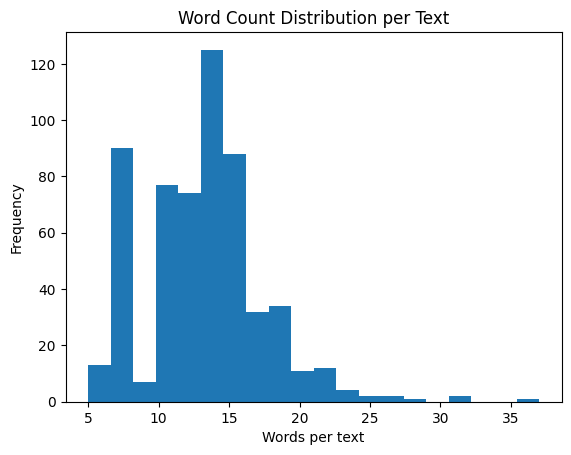

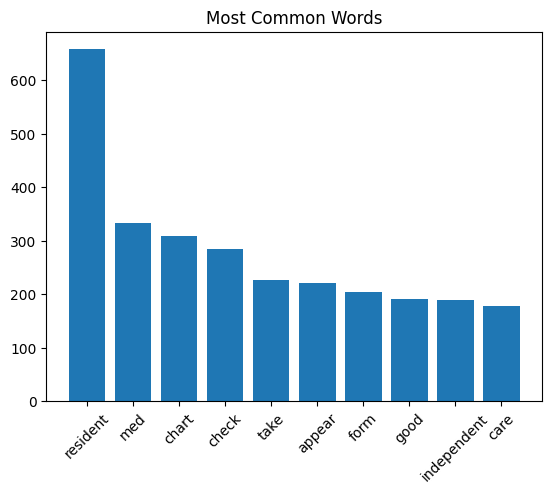

-----------P6-----------
----- General Stats -----
Number of texts: 605
Total words: 11257
Unique words (vocab size): 724
----- Length Stats -----
Average text length (characters): 123.31404958677686
Average word count per text: 18.606611570247935
Shortest text word count: 5
Longest text word count: 147
----- Most Common N-GRAMS -----
('safety', 'check') -> 193
('resident', 'appear') -> 182
('check', 'continue') -> 150
('settle', 'sleep') -> 116
('resident', 'settle') -> 114
('form', 'assist') -> 109
('give', 'chart') -> 108
('continue', 'overnight') -> 96
('medication', 'administer') -> 94
('care', 'need') -> 93
----- Most Common Words -----
resident -> 614
care -> 333
bed -> 331
assist -> 282
give -> 279
medication -> 263
appear -> 256
check -> 246
nil -> 238
sleep -> 225
----- Sentiment -----
Average polarity: 0.15333333333333332


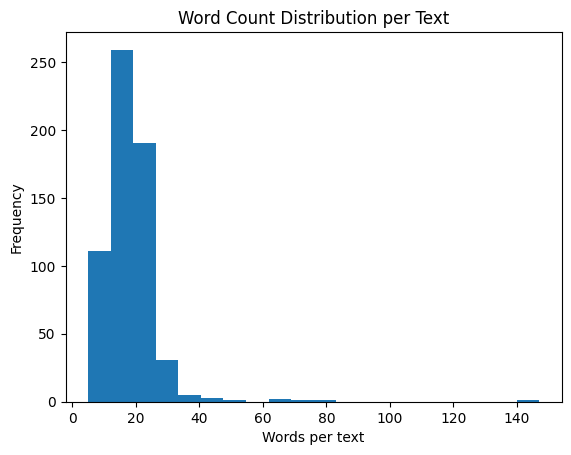

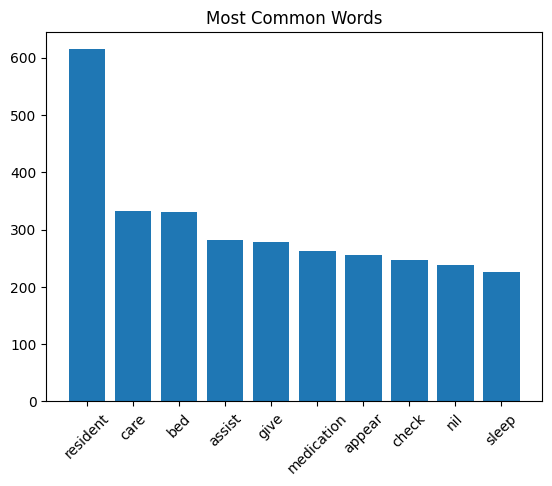

-----------P7-----------
----- General Stats -----
Number of texts: 586
Total words: 9390
Unique words (vocab size): 487
----- Length Stats -----
Average text length (characters): 105.85494880546075
Average word count per text: 16.023890784982935
Shortest text word count: 5
Longest text word count: 47
----- Most Common N-GRAMS -----
('resident', 'appear') -> 171
('safety', 'check') -> 153
('med', 'give') -> 145
('check', 'continue') -> 138
('resident', 'settle') -> 137
('give', 'chart') -> 128
('good', 'form') -> 121
('settle', 'sleep') -> 110
('new', 'concern') -> 103
('self', 'toilete') -> 102
----- Most Common Words -----
resident -> 592
good -> 316
care -> 286
give -> 276
med -> 246
assist -> 235
sleep -> 232
medication -> 231
concern -> 226
check -> 223
----- Sentiment -----
Average polarity: 0.38


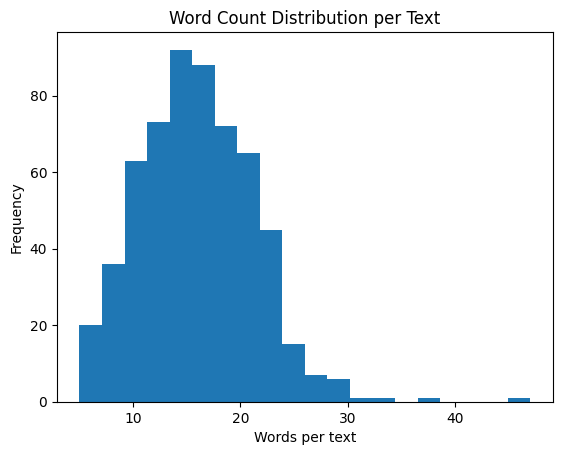

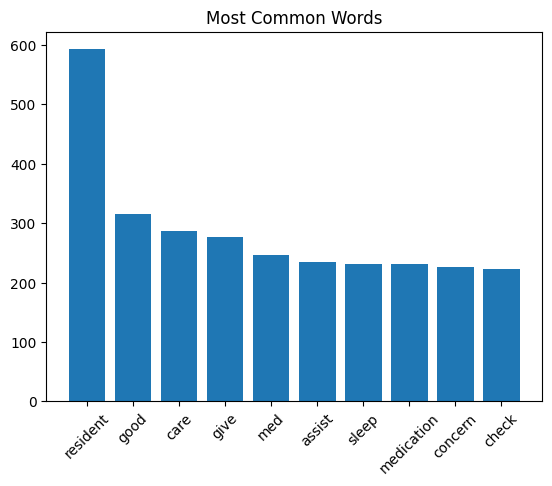

-----------P8-----------
----- General Stats -----
Number of texts: 690
Total words: 14246
Unique words (vocab size): 1202
----- Length Stats -----
Average text length (characters): 137.2159420289855
Average word count per text: 20.6463768115942
Shortest text word count: 5
Longest text word count: 221
----- Most Common N-GRAMS -----
('safety', 'check') -> 177
('resident', 'appear') -> 168
('care', 'need') -> 166
('check', 'continue') -> 136
('good', 'form') -> 115
('need', 'attend') -> 113
('form', 'assist') -> 112
('give', 'chart') -> 105
('med', 'give') -> 92
('nil', 'new') -> 90
----- Most Common Words -----
resident -> 725
care -> 399
assist -> 359
bed -> 277
give -> 272
medication -> 259
nil -> 243
med -> 227
check -> 223
need -> 220
----- Sentiment -----
Average polarity: 0.11409090909090909


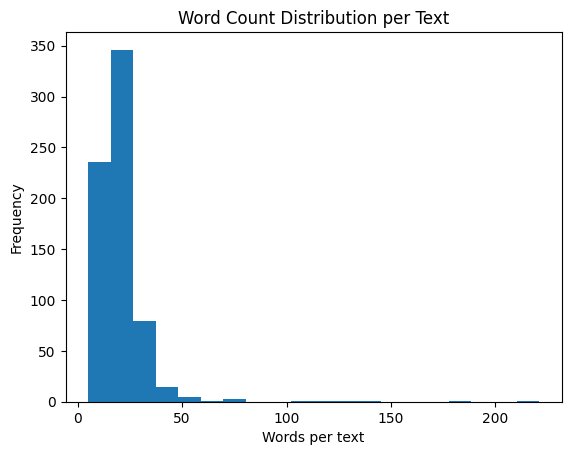

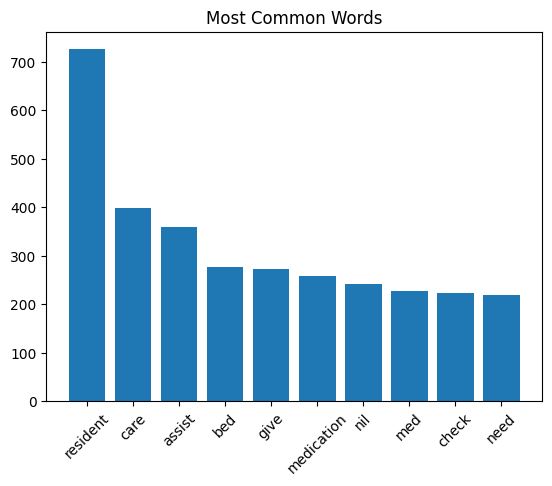

-----------P9-----------
----- General Stats -----
Number of texts: 624
Total words: 11884
Unique words (vocab size): 835
----- Length Stats -----
Average text length (characters): 123.65544871794872
Average word count per text: 19.044871794871796
Shortest text word count: 5
Longest text word count: 72
----- Most Common N-GRAMS -----
('safety', 'check') -> 323
('resident', 'appear') -> 226
('take', 'chart') -> 153
('good', 'form') -> 152
('med', 'take') -> 139
('care', 'need') -> 139
('settle', 'night') -> 131
('check', 'maintain') -> 126
('nil', 'new') -> 114
('sensor', 'mat') -> 109
----- Most Common Words -----
resident -> 647
check -> 427
care -> 421
need -> 370
safety -> 330
chart -> 298
assist -> 293
med -> 283
take -> 280
appear -> 252
----- Sentiment -----
Average polarity: 0.12898701298701298


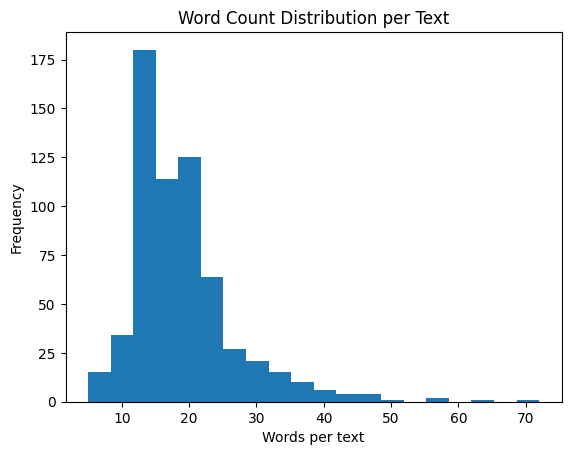

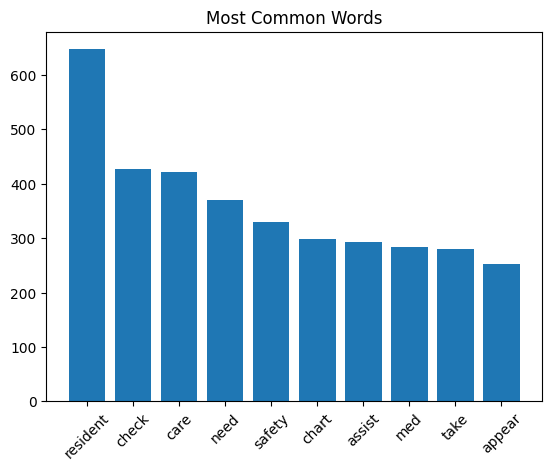

In [9]:
all_texts = []
for key in nurse_notes.keys():
    print(f"-----------{key}-----------")
    text_statistics(nurse_notes[key])
    plot_word_distribution(nurse_notes[key])
    plot_top_words(nurse_notes[key], 10)
    all_texts.extend(nurse_notes[key])

----- General Stats -----
Number of texts: 12225
Total words: 205157
Unique words (vocab size): 3224
----- Length Stats -----
Average text length (characters): 110.58044989775051
Average word count per text: 16.781758691206544
Shortest text word count: 5
Longest text word count: 221
----- Most Common N-GRAMS -----
('resident', 'appear') -> 3631
('safety', 'check') -> 3453
('care', 'need') -> 3213
('good', 'form') -> 3170
('give', 'chart') -> 2271
('med', 'take') -> 2264
('take', 'chart') -> 1950
('appear', 'good') -> 1934
('med', 'give') -> 1836
('check', 'continue') -> 1810
----- Most Common Words -----
resident -> 12471
care -> 7930
check -> 5884
med -> 5373
assist -> 5302
need -> 5184
chart -> 4841
appear -> 4544
good -> 4513
nil -> 4336
----- Sentiment -----
Average polarity: 0.11833333333333333


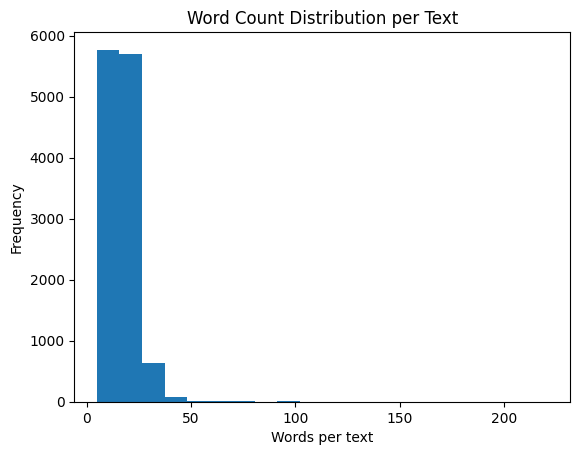

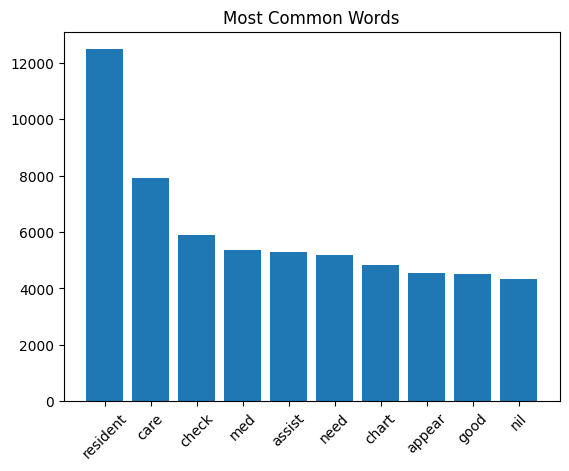

In [10]:
text_statistics(all_texts)
plot_word_distribution(all_texts)
plot_top_words(all_texts, 10)